# CMS Medicare Provider Utilization — SQL & Python Analysis
**Author:** Simran Randhawa  
**Data:** Medicare Physician & Other Practitioners by Provider and Service (2023)  
**Source:** data.cms.gov | Filtered to Maryland providers

## Notebook Overview
This notebook loads CMS Medicare utilization data, cleans it with pandas,
loads it into a SQLite database, and runs SQL queries to answer real
healthcare questions about provider billing patterns in Maryland.

**Analysis questions:**
1. Which medical specialties have the highest average Medicare payments?
2. Which services are billed most frequently?
3. How do payment amounts vary across provider types?
4. Which providers have the highest total Medicare payments?

**Tools:** Python, pandas, SQLite, seaborn, matplotlib

In [1]:
# ── Cell 2: Import libraries ──────────────────────────────────
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries loaded.")
print(f"pandas: {pd.__version__}")
print(f"sqlite3: {sqlite3.version}")

Libraries loaded.
pandas: 3.0.2
sqlite3: 2.6.0


/var/folders/bz/90kmc8jj57537qrvcvrsc97r0000gn/T/ipykernel_62985/3932835191.py:14: DeprecationWarning: version is deprecated and will be removed in Python 3.14
  print(f"sqlite3: {sqlite3.version}")


## Step 1: Load and Inspect the Raw Data

In [2]:
# Load the CMS data
filename = "Medicare_Physician_Other_Practitioners_by_Provider_and_Service_2023.csv"

df = pd.read_csv(filename, low_memory=False)

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{list(df.columns)}")

Shape: (223406, 28)

Columns:
['Rndrng_NPI', 'Rndrng_Prvdr_Last_Org_Name', 'Rndrng_Prvdr_First_Name', 'Rndrng_Prvdr_MI', 'Rndrng_Prvdr_Crdntls', 'Rndrng_Prvdr_Ent_Cd', 'Rndrng_Prvdr_St1', 'Rndrng_Prvdr_St2', 'Rndrng_Prvdr_City', 'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_State_FIPS', 'Rndrng_Prvdr_Zip5', 'Rndrng_Prvdr_RUCA', 'Rndrng_Prvdr_RUCA_Desc', 'Rndrng_Prvdr_Cntry', 'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_Mdcr_Prtcptg_Ind', 'HCPCS_Cd', 'HCPCS_Desc', 'HCPCS_Drug_Ind', 'Place_Of_Srvc', 'Tot_Benes', 'Tot_Srvcs', 'Tot_Bene_Day_Srvcs', 'Avg_Sbmtd_Chrg', 'Avg_Mdcr_Alowd_Amt', 'Avg_Mdcr_Pymt_Amt', 'Avg_Mdcr_Stdzd_Amt']


## Step 2: Clean the Data

In [3]:
# ── Rename columns for readability ───────────────────────────
df_clean = df.rename(columns={
    'Rndrng_NPI': 'provider_npi',
    'Rndrng_Prvdr_Last_Org_Name': 'last_name',
    'Rndrng_Prvdr_First_Name': 'first_name',
    'Rndrng_Prvdr_City': 'city',
    'Rndrng_Prvdr_State_Abrvtn': 'state',
    'Rndrng_Prvdr_Zip5': 'zip',
    'Rndrng_Prvdr_Type': 'specialty',
    'Rndrng_Prvdr_Ent_Cd': 'entity_type',
    'HCPCS_Cd': 'hcpcs_code',
    'HCPCS_Desc': 'service_description',
    'HCPCS_Drug_Ind': 'drug_indicator',
    'Place_Of_Srvc': 'place_of_service',
    'Tot_Benes': 'total_beneficiaries',
    'Tot_Srvcs': 'total_services',
    'Avg_Sbmtd_Chrg': 'avg_submitted_charge',
    'Avg_Mdcr_Alowd_Amt': 'avg_medicare_allowed',
    'Avg_Mdcr_Pymt_Amt': 'avg_medicare_payment',
    'Avg_Mdcr_Stdzd_Amt': 'avg_standardized_payment'
})

# ── Check missing values ──────────────────────────────────────
print("Missing values in key columns:")
key_cols = ['specialty', 'service_description', 'avg_medicare_payment',
            'total_services', 'total_beneficiaries']
print(df_clean[key_cols].isna().sum())

# ── Drop rows missing critical fields ────────────────────────
df_clean = df_clean.dropna(subset=['avg_medicare_payment', 'total_services', 'specialty'])

# ── Convert numeric columns ───────────────────────────────────
numeric_cols = ['avg_medicare_payment', 'total_services', 
                'avg_submitted_charge', 'avg_medicare_allowed',
                'total_beneficiaries']
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# ── Add total payment column ──────────────────────────────────
df_clean['total_medicare_payment'] = df_clean['avg_medicare_payment'] * df_clean['total_services']

print(f"\nClean dataset shape: {df_clean.shape}")
print(f"Unique specialties: {df_clean['specialty'].nunique()}")
print(f"Unique services: {df_clean['service_description'].nunique()}")

Missing values in key columns:
specialty               0
service_description     0
avg_medicare_payment    0
total_services          0
total_beneficiaries     0
dtype: int64

Clean dataset shape: (223406, 29)
Unique specialties: 93
Unique services: 3226


## Step 3: Load Data into SQLite Database
Creating a SQL database from the cleaned pandas dataframe — this demonstrates
building a queryable database from raw data, a common real-world workflow.

In [4]:
# ── Create SQLite database ────────────────────────────────────
conn = sqlite3.connect('cms_maryland.db')

# Load clean dataframe into SQL table
df_clean.to_sql('medicare_providers', conn, if_exists='replace', index=False)

print("Database created: cms_maryland.db")
print(f"Table 'medicare_providers' loaded with {len(df_clean)} rows")

# Verify with a quick SQL query
test = pd.read_sql_query("SELECT COUNT(*) as total_rows FROM medicare_providers", conn)
print(f"\nSQL verification — total rows: {test['total_rows'][0]}")

Database created: cms_maryland.db
Table 'medicare_providers' loaded with 223406 rows

SQL verification — total rows: 223406


## Step 4: SQL Analysis
Running SQL queries to answer healthcare business questions about Maryland Medicare providers.

In [5]:
# ── Query 1: Top 10 specialties by average Medicare payment ──
q1 = pd.read_sql_query("""
    SELECT 
        specialty,
        COUNT(DISTINCT provider_npi) as num_providers,
        ROUND(AVG(avg_medicare_payment), 2) as avg_payment,
        ROUND(SUM(total_medicare_payment), 2) as total_payments,
        SUM(total_services) as total_services
    FROM medicare_providers
    GROUP BY specialty
    HAVING num_providers >= 10
    ORDER BY avg_payment DESC
    LIMIT 10
""", conn)

print("Top 10 Specialties by Average Medicare Payment:")
print(q1.to_string(index=False))

Top 10 Specialties by Average Medicare Payment:
                 specialty  num_providers  avg_payment  total_payments  total_services
Ambulatory Surgical Center            259      1064.49    175247989.26       669767.00
          Vascular Surgery             87       457.75     35748074.36       223662.10
           Cardiac Surgery             19       446.86      1261629.39         3097.00
          Thoracic Surgery             29       435.60      6756051.54        28879.00
              Neurosurgery             97       328.79      9558936.91        46104.00
Ambulance Service Provider            119       293.02    104304836.47      2520089.50
    Gynecological Oncology             21       195.74      1577202.71        11703.00
         Surgical Oncology             21       193.92       733931.75         5152.00
  Interventional Radiology             38       179.42     10128332.34        40211.00
        Radiation Oncology             90       176.37     37924495.78       26618

In [6]:
# ── Query 2: Most frequently billed services ─────────────────
q2 = pd.read_sql_query("""
    SELECT 
        service_description,
        SUM(total_services) as total_billed,
        ROUND(AVG(avg_medicare_payment), 2) as avg_payment,
        COUNT(DISTINCT provider_npi) as num_providers
    FROM medicare_providers
    GROUP BY service_description
    ORDER BY total_billed DESC
    LIMIT 10
""", conn)

print("Top 10 Most Billed Services:")
print(q2.to_string(index=False))

Top 10 Most Billed Services:
                                                                                               service_description  total_billed  avg_payment  num_providers
                                         Low osmolar contrast material, 300-399 mg/ml iodine concentration, per ml    4005063.00         0.11            326
                                                                           Injection, gadoterate meglumine, 0.1 ml    2991178.00         0.11            139
                                               Established patient office or other outpatient visit, 30-39 minutes    2904537.00        84.53          10274
                                                                       Chloroprocaine hcl ophthalmic, 3% gel, 1 mg    2766401.00         0.55              3
                                                                                  Ground mileage, per statute mile    2243198.70         7.31            118
                             

In [7]:
# ── Query 3: Top providers by total Medicare payments ─────────
q3 = pd.read_sql_query("""
    SELECT 
        first_name || ' ' || last_name as provider_name,
        specialty,
        city,
        ROUND(SUM(total_medicare_payment), 2) as total_payments,
        SUM(total_services) as total_services,
        COUNT(DISTINCT hcpcs_code) as unique_services
    FROM medicare_providers
    GROUP BY provider_npi
    ORDER BY total_payments DESC
    LIMIT 10
""", conn)

print("Top 10 Providers by Total Medicare Payments:")
print(q3.to_string(index=False))

Top 10 Providers by Total Medicare Payments:
    provider_name                  specialty         city  total_payments  total_services  unique_services
              NaN    Portable X-Ray Supplier       Sparks     42021791.73      1258190.00               83
              NaN        Clinical Laboratory    Baltimore     27336483.33      2327366.00              542
     David Warrow              Ophthalmology   Hagerstown     15061229.82      1539669.00               35
              NaN Ambulance Service Provider       Towson     12156472.54       205485.40                4
   Michael Morris       Diagnostic Radiology  Glen Burnie     11954936.53        71700.00               35
              NaN Ambulance Service Provider Gaithersburg     10829003.09       141003.80                4
 William Sharfman           Medical Oncology  Lutherville      9137963.94       223792.00               31
Carmen Salvaterra          Pulmonary Disease     Columbia      8942880.82        57458.00          

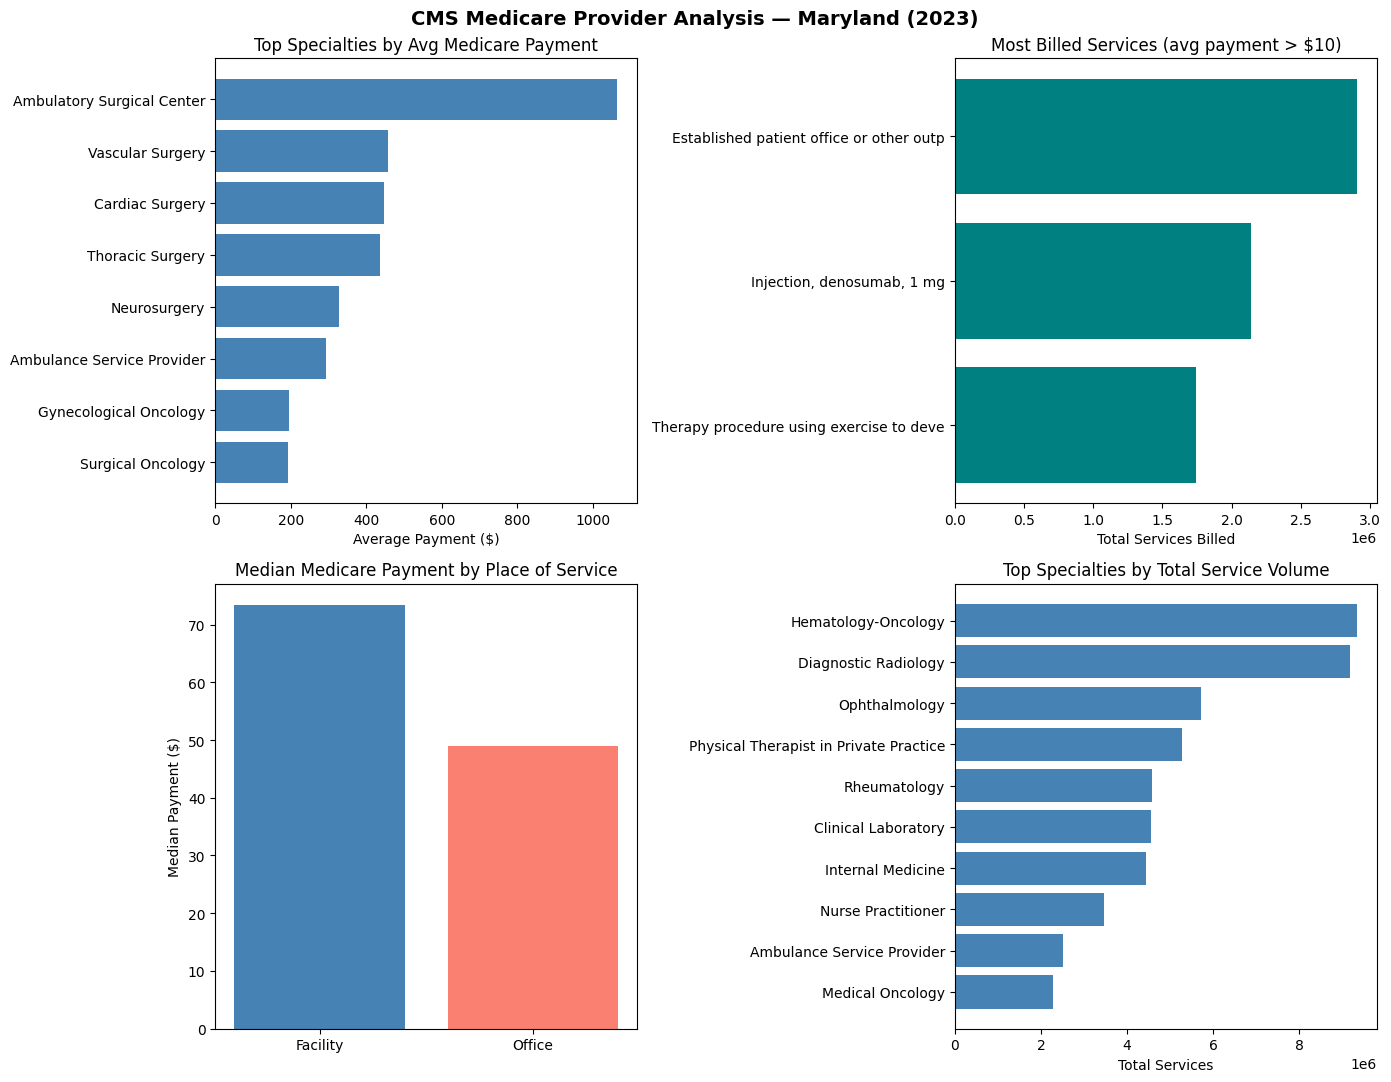

Plot saved.


In [8]:
# Visualizations
os.makedirs('results', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('CMS Medicare Provider Analysis — Maryland (2023)', 
             fontsize=14, fontweight='bold')

# Plot 1: Top specialties by avg payment
axes[0,0].barh(q1['specialty'][:8], q1['avg_payment'][:8], color='steelblue')
axes[0,0].set_title('Top Specialties by Avg Medicare Payment')
axes[0,0].set_xlabel('Average Payment ($)')
axes[0,0].invert_yaxis()

# Plot 2: Most billed services (filter out drug/supply codes)
q2_filtered = q2[q2['avg_payment'] > 10].head(8)
axes[0,1].barh(q2_filtered['service_description'].str[:40], 
               q2_filtered['total_billed'], color='teal')
axes[0,1].set_title('Most Billed Services (avg payment > $10)')
axes[0,1].set_xlabel('Total Services Billed')
axes[0,1].invert_yaxis()

# Plot 3: Payment distribution by place of service
place_data = df_clean.groupby('place_of_service')['avg_medicare_payment'].median().reset_index()
place_data['place_of_service'] = place_data['place_of_service'].map(
    {'F': 'Facility', 'O': 'Office'})
axes[1,0].bar(place_data['place_of_service'], 
              place_data['avg_medicare_payment'], color=['steelblue','salmon'])
axes[1,0].set_title('Median Medicare Payment by Place of Service')
axes[1,0].set_ylabel('Median Payment ($)')

# Plot 4: Top 10 specialties by total volume
q4 = pd.read_sql_query("""
    SELECT specialty, SUM(total_services) as total_vol
    FROM medicare_providers
    GROUP BY specialty
    ORDER BY total_vol DESC
    LIMIT 10
""", conn)
axes[1,1].barh(q4['specialty'], q4['total_vol'], color='steelblue')
axes[1,1].set_title('Top Specialties by Total Service Volume')
axes[1,1].set_xlabel('Total Services')
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.savefig('results/01_cms_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

/var/folders/bz/90kmc8jj57537qrvcvrsc97r0000gn/T/ipykernel_62985/1336842724.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top,


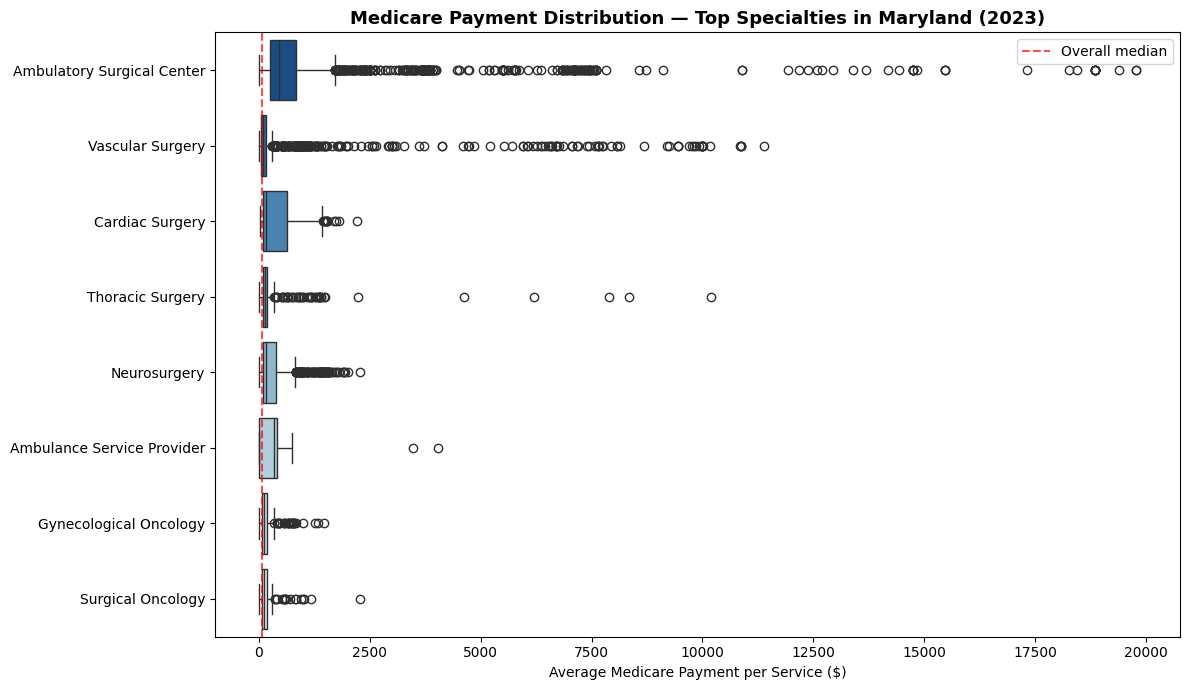

Plot saved.


In [9]:
#Seaborn: Payment distribution for top 8 specialties 
top_specialties = q1['specialty'].head(8).tolist()
df_top = df_clean[df_clean['specialty'].isin(top_specialties)]

fig2, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(data=df_top, 
            x='avg_medicare_payment', 
            y='specialty',
            palette='Blues_r',
            order=top_specialties,
            ax=ax)
ax.set_title('Medicare Payment Distribution — Top Specialties in Maryland (2023)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Average Medicare Payment per Service ($)')
ax.set_ylabel('')
ax.axvline(df_clean['avg_medicare_payment'].median(), 
           color='red', linestyle='--', alpha=0.7, label='Overall median')
ax.legend()

plt.tight_layout()
plt.savefig('results/02_payment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

In [10]:
#Close database connection 
conn.close()
print("Analysis complete. Database connection closed.")
print("\nFiles saved:")
print("  results/01_cms_analysis.png")
print("  results/02_payment_distribution.png")
print("  cms_maryland.db")

Analysis complete. Database connection closed.

Files saved:
  results/01_cms_analysis.png
  results/02_payment_distribution.png
  cms_maryland.db
